# SA ↔ RFSoC standby-detector correlation

Put the spectrum-analyser traces from a `FeedbackWithRFSoC` run and the on-FPGA
RFSoC standby detector on **one wall-clock timeline**.

**To reuse: change `RID` in the next cell and Run All.**

The helper lives in `edes.experiments.analysis.sa_rfsoc_corr`. It reads the ARTIQ
`.h5` (auto-found under `ARTIQ_RESULTS`) and the RFSoC session directory named in
the run's `rfsoc_fetch_dir` dataset.


In [1]:
RID = 11345          # <-- the only thing you normally change
bg_RID = 11338
%matplotlib inline
import importlib
from edes.experiments.analysis import sa_rfsoc_corr as C
importlib.reload(C)
# C.RESULTS_ROOT / C.RFSOC_DATA_ROOT can be overridden here if your paths differ
run = C.load_run(RID)

## 1. Summary  —  counts, threshold, and every event on the timeline

`event_count` = crossings that triggered a DDR4 capture &nbsp;·&nbsp;
`crossings_total` = every threshold crossing &nbsp;·&nbsp;
`pulse_fired` = crossings that drove the feedback pulse.

In [2]:
C.summary(run)

RID 11345   000011345-FeedbackWithRFSoC.h5
  session   artiq_11345_20260915_165925   fetch_dir=/home/electron/data/RFSoc_data/artiq_11345_20260915_165925
  board t_start 1789516783.270   elapsed 581.5106611251831 s   pps 525118
  v_thresh 16780   calib={'v_thresh': 16780, 'calibrated': True, 'source': 'external', 'calib_tag': 'shared'}
  counts: crossings_total=1  event_count(DDR4)=1  events_saved=1  pulse_fired=1  mr=0  missed=0
  SA: 0 saved trace(s) over 0 rep(s)   P_thresh -62.0 dBm   [SA anchor = sweep-END, +*OPC?/transfer lag ~10-40 ms]
  DDR4 events:
    1789516792.398  (+9.1 s)  amp=23944  event_000001.npz   (no SA trace)


## 2. Timeline overlay

x = seconds since the RFSoC session started (board wall clock). Left axis =
RFSoC detector metric (same units as `v_thresh`); right axis = SA peak power.

* grey stems/dots  — RFSoC threshold crossings
* blue stars       — DDR4 window captures (`event_*.npz`)
* orange triangles — MR fallback snapshots (`event_mr_*.npz`)
* green squares     — SA traces that were saved (peak above `P_signal_threshold`)


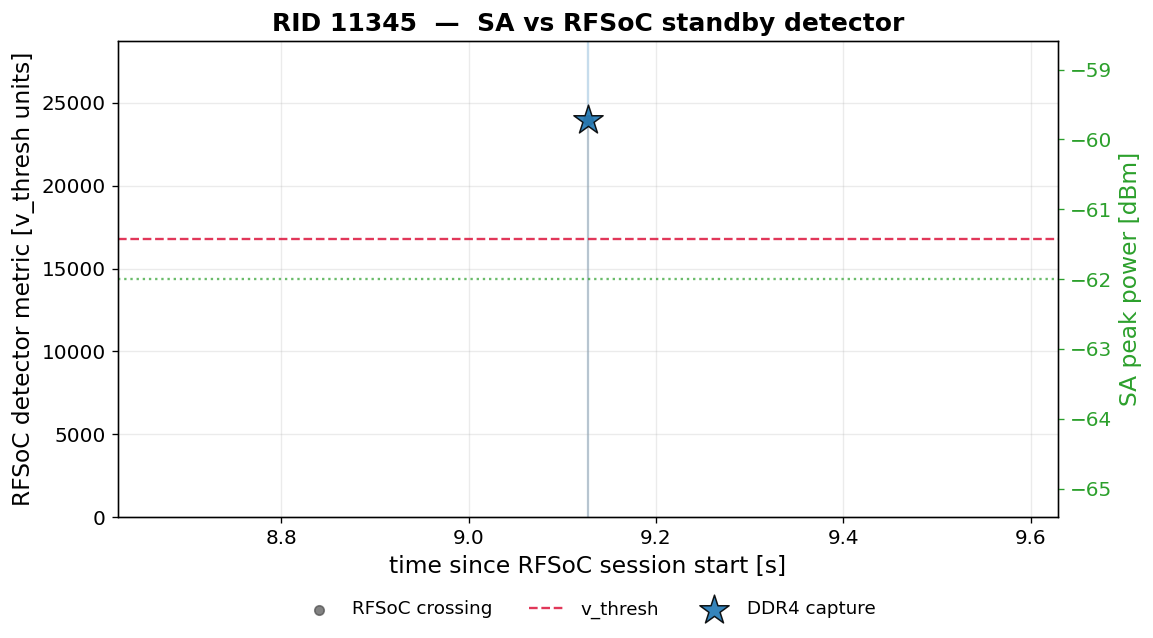

In [15]:
C.plot_timeline(run);

## 3. The saved SA spectra

In [16]:
C.plot_sa_traces(run);

no SA traces saved in this run


## 4. The DDR4 capture windows

`|I,Q| = sqrt(I²+Q²)` per sample. **Solid = per-bin mean** (the signal level);
the pale band is the min–max. The feedback pulse plays over roughly the first
`pulse_length_us`. Needs `rfsoc_fetch = 'full'` on the run.

`db=True` → `20·log10|I,Q|` [dB]; `db_ref=` sets 0 dB &nbsp;·&nbsp;
`envelope=False` → mean line only &nbsp;·&nbsp;
`pulse=True` → overlay the programmed feedback pulse (from `rfsoc_pulse_spec`)
on a twin right axis, offset by the crossing→RF latency (`pulse_offset_us=`
to override).

<Axes: title={'center': 'RID 11345   1 DDR4 capture window(s) overlaid   +9.1–9.1 s'}, xlabel='time in capture window [ms]  —  pulse plays over the first ~pulse_length_us', ylabel='|I,Q|'>

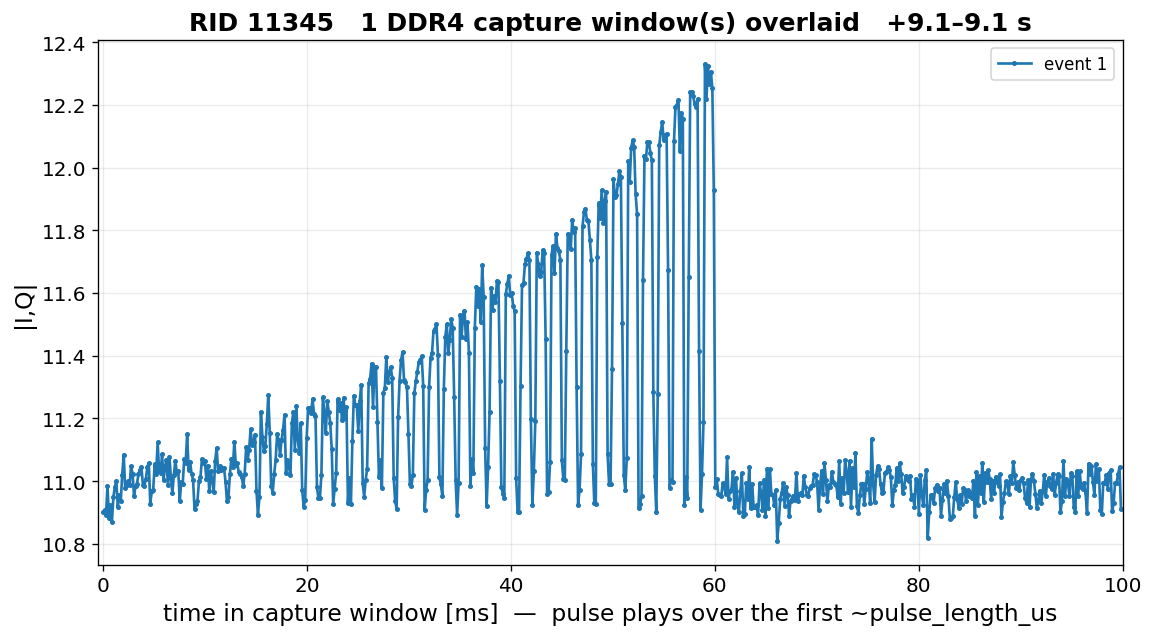

In [17]:
# C.plot_ddr4_events(run, pulse=True)
# C.plot_ddr4_events(run, db=False, envelope=False, pulse=False, decimation = 80000, xlim=(0, 100),ylim=(10.8,12.7),time_unit = "ms",linestyle= '.-')
C.plot_ddr4_events_overlay(run, db=False, envelope=False, pulse=False, decimation = 80000, xlim=(-0.5, 100),time_unit = "ms",linestyle= '.-')

(<Axes: title={'center': 'DDR4 (decimation=1000)— 12 event(s) from RID 11345, RID_11338 [bg]'}, ylabel='|I,Q|'>,
 <Axes: xlabel='time in capture window [ms]', ylabel='|I,Q|'>)

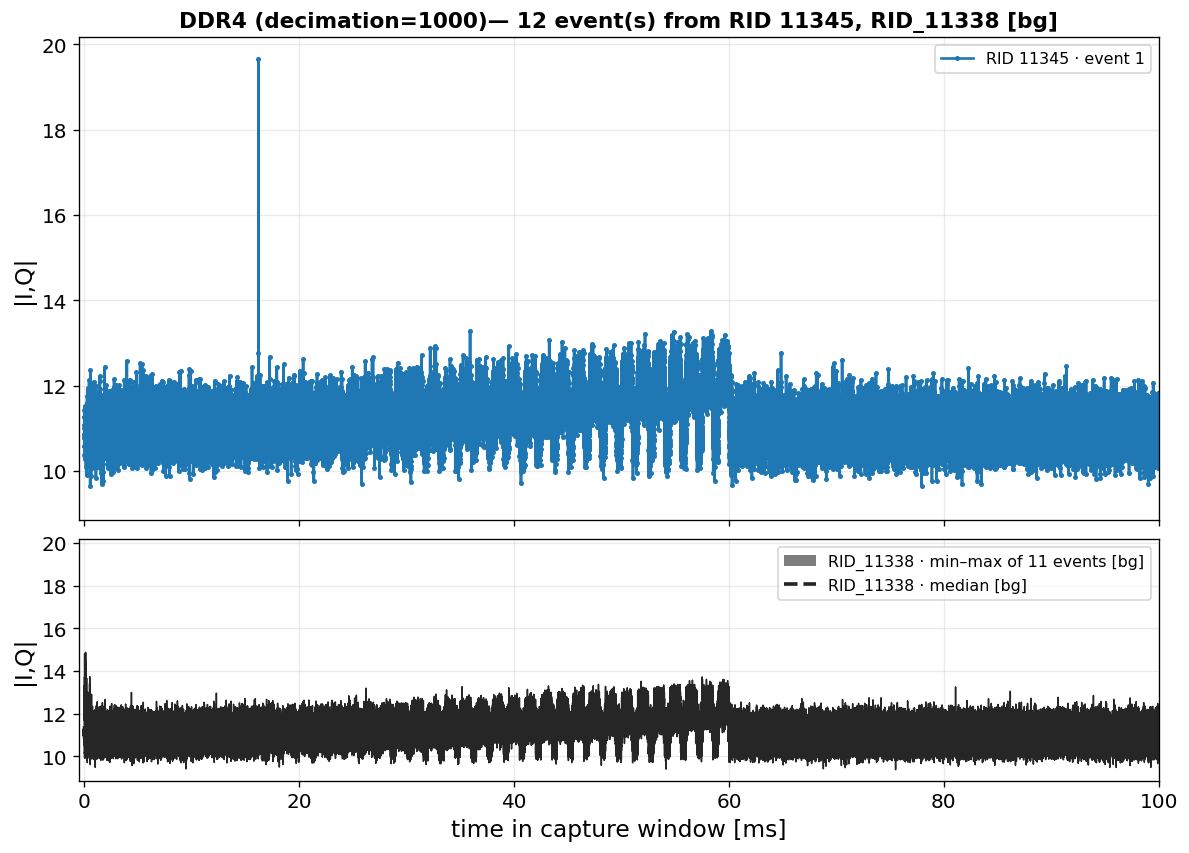

In [18]:
C.plot_ddr4_events_multi(
    [run, {"rid": bg_RID, "label": "RID_11338", "noise": True}],
    time_unit="ms", envelope=False, decimation=1000, xlim=(-0.5, 100),
    linestyle='.-', db=False, split=True, noise_band=True)

[<Axes: title={'center': 'RID 11345   event_000001.npz   +9.1 s   crossing amp 23944   + feedback pulse'}, xlabel='time in capture window [ms]', ylabel='|I,Q|'>]

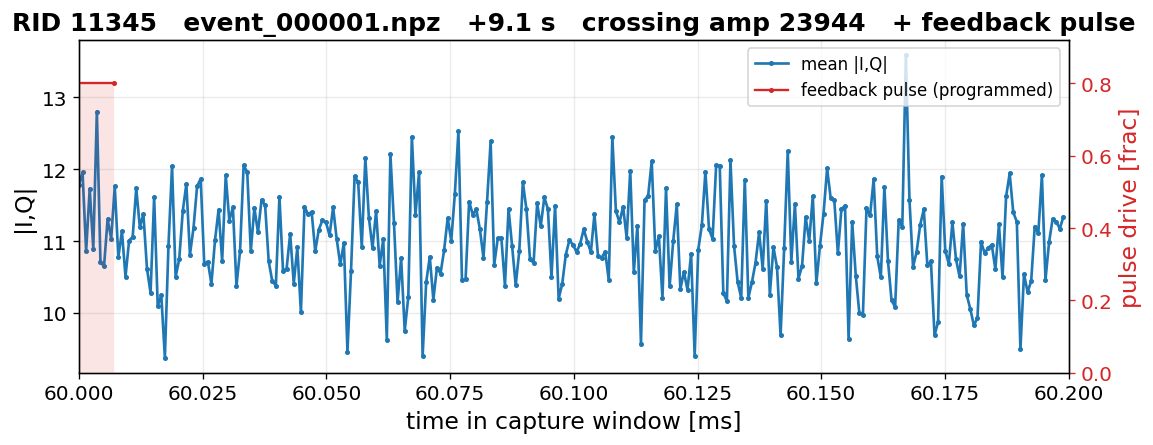

In [ ]:
# C.plot_ddr4_events(run, pulse=True)
C.plot_ddr4_events(run, db=False, envelope=False, pulse=True, decimation = 400, xlim=(60.0, 60.2),time_unit = "ms",linestyle= '.-')

<Axes: title={'center': 'DDR4 (decimation=10000)— 10 event(s) from RID 11333, RID 11335 [bg]'}, xlabel='time in capture window [ms]', ylabel='|I,Q|'>

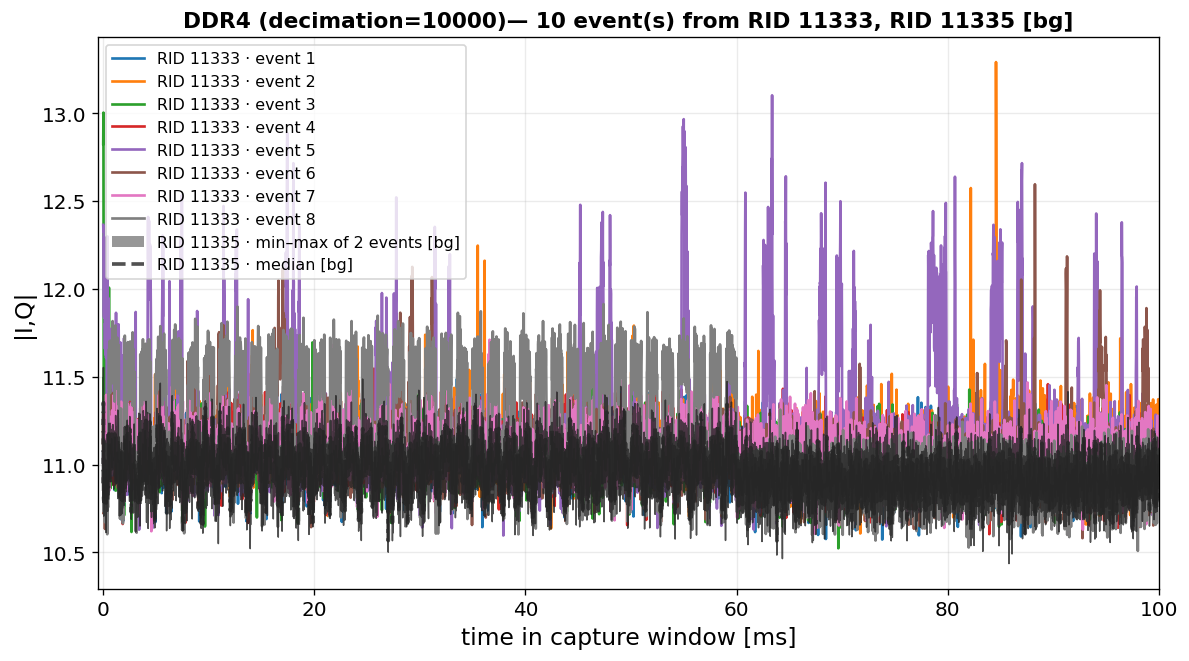

In [41]:
C.plot_ddr4_events_multi([11333], noise=11335, decimation=10000, 
                         time_unit="ms", xlim=(-0.5, 100),noise_band=True)

<Axes: title={'center': 'DDR4 background-subtracted (amp, decimation=10000) — 8 event(s) vs RID 11335 ·\nmean of 2 capture(s)'}, xlabel='time in capture window [ms]', ylabel='|I,Q| − background'>

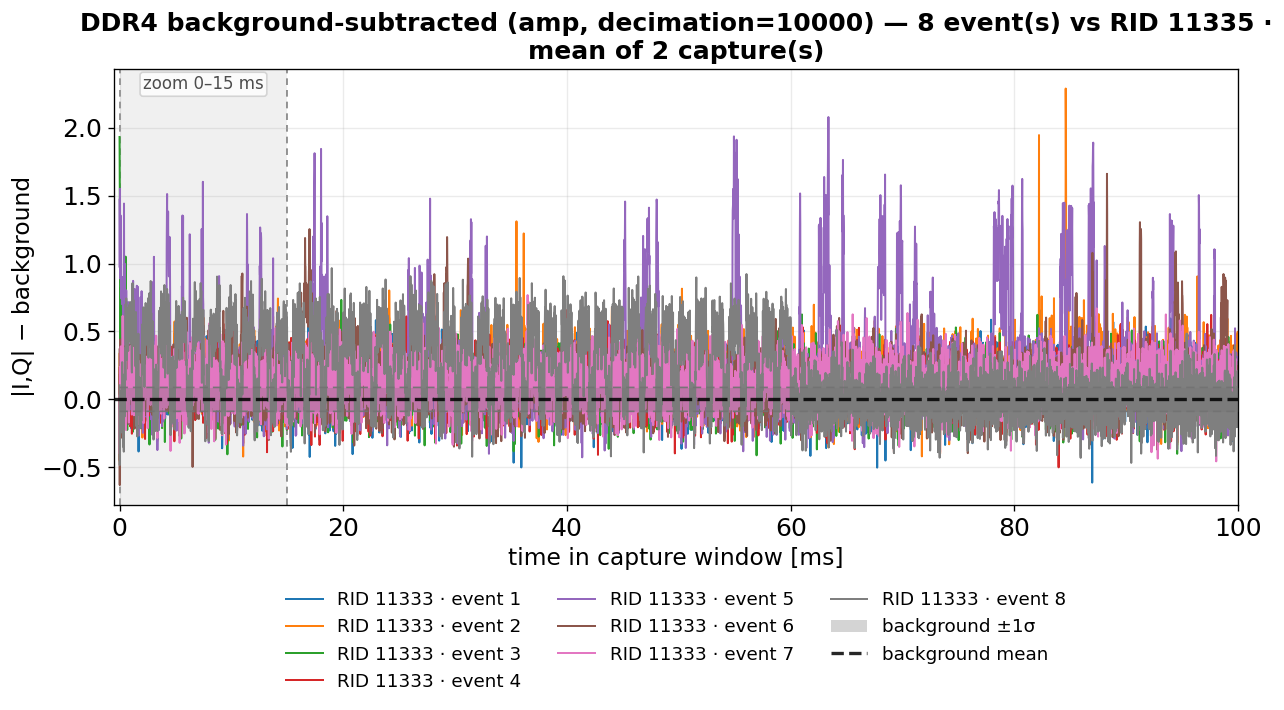

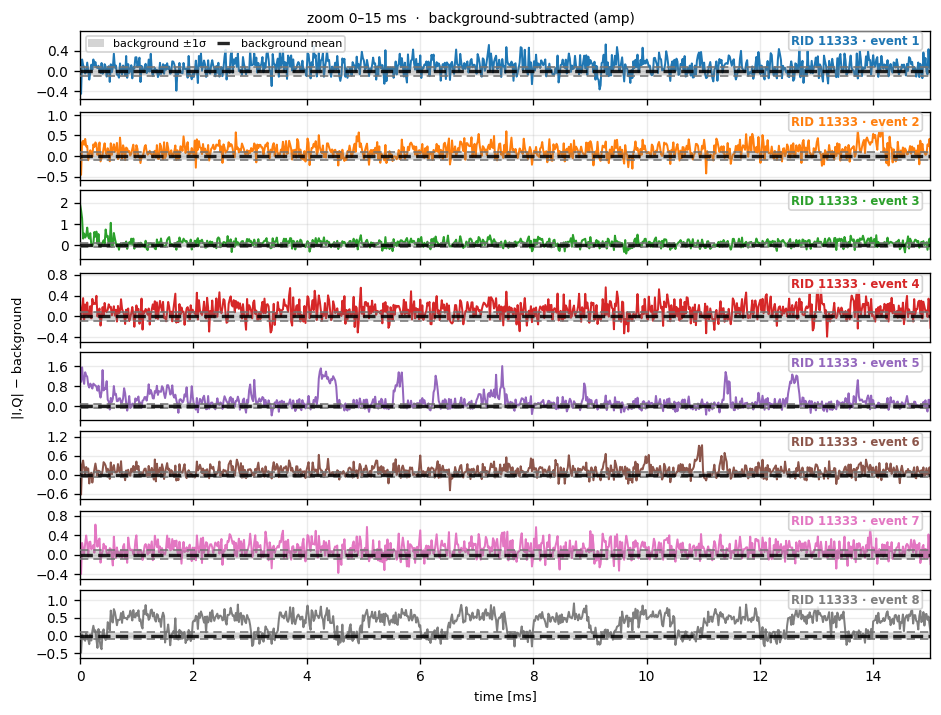

In [40]:
C.plot_ddr4_events_bgsub([11333], noise=11335, decimation=10000, 
                         time_unit="ms", xlim=(-0.5, 100), zoom=(0,15))#, ylim=(-0.5, 1.5), envelope=False, pulse=False, db=False, linestyle='.-', split=True)

[<Axes: title={'center': 'RID 11345   event_000001.npz   +9.1 s   crossing amp 23944   + feedback pulse'}, xlabel='time in capture window [ms]', ylabel='|I,Q|'>]

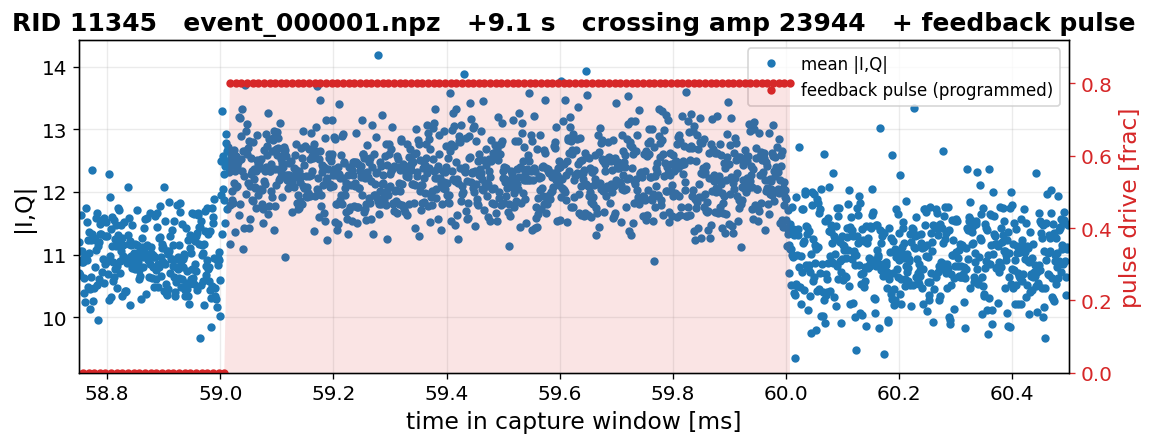

In [21]:
C.plot_ddr4_events(run, db=False, envelope=False, pulse=True, decimation = 500, xlim=(58.75, 60.5),time_unit = "ms",linestyle= 'o')

## 5. SA trace vs DDR4 window — shared time axis

One SA trace and one DDR4 capture on the **same** x-axis (ms relative to the
DDR4 crossing). SA in dBm; DDR4 `|I,Q|` as `20·log10|I,Q|`, median-matched.

**Alignment** (auto):
* runs with `sa_wall_start_*` **and** `sa_wall_*` → the SSA_SWT sweep sits
  somewhere in `[start, end − SSA_SWT]`; the SA trace is anchored at the
  MIDPOINT and the plot shades the residual **±overhead/2** (on this bench
  the overhead is ~80 ms → ±40 ms, because `*OPC?`/transfer dominate). A
  hardware/level trigger is the only way to beat that.
* only `sa_wall_*` → `end − SSA_SWT`; add the lag with `sa_latency_ms=`
* pre-patch → ±10 s estimate; use `shift_ms=`

The SA sweep is not *signal-triggered*, so a burst lands at an arbitrary
phase of the window — **the RFSoC crossing (x=0) is the reliable timestamp**.

Other knobs: `sa=`, `event=`, `sep_axis=True`, `which='peak'`, `xlim_ms=(a,b)`.

In [22]:
C.plot_sa_vs_ddr4(run, sa=0, event=-1, sa_latency_ms=0);
# then try sa_latency_ms=18, xlim_ms=(-30, 40) to see the burst land on x=0

need at least one SA trace and one DDR4 event



RF spectrum — RBW 1.00 kHz, 133 averages
  RID 11333 · event 1          peak   351.4000 MHz     2.6 dBm   floor   -39.9 dBm
  RID 11333 · event 4          peak    -0.6000 MHz     0.3 dBm   floor   -39.9 dBm
  RID 11333 · event 8          peak    -0.6000 MHz     7.1 dBm   floor   -40.0 dBm
  RID 11335 · mean of 2 capture(s) [bg] peak   351.4000 MHz     2.5 dBm   floor   -40.1 dBm

Band 175.995–175.706 MHz kept (-289 kHz wide)
  RID 11335 · mean ± 1σ of 2 capture(s) [bg] level    0.960 ± 0.101   (counts)
  RID 11333 · event 1          rms    1.043   peak     3.61   (counts)
  RID 11333 · event 4          rms    1.060   peak     4.01   (counts)
  RID 11333 · event 8          rms    0.709   peak     2.72   (counts)


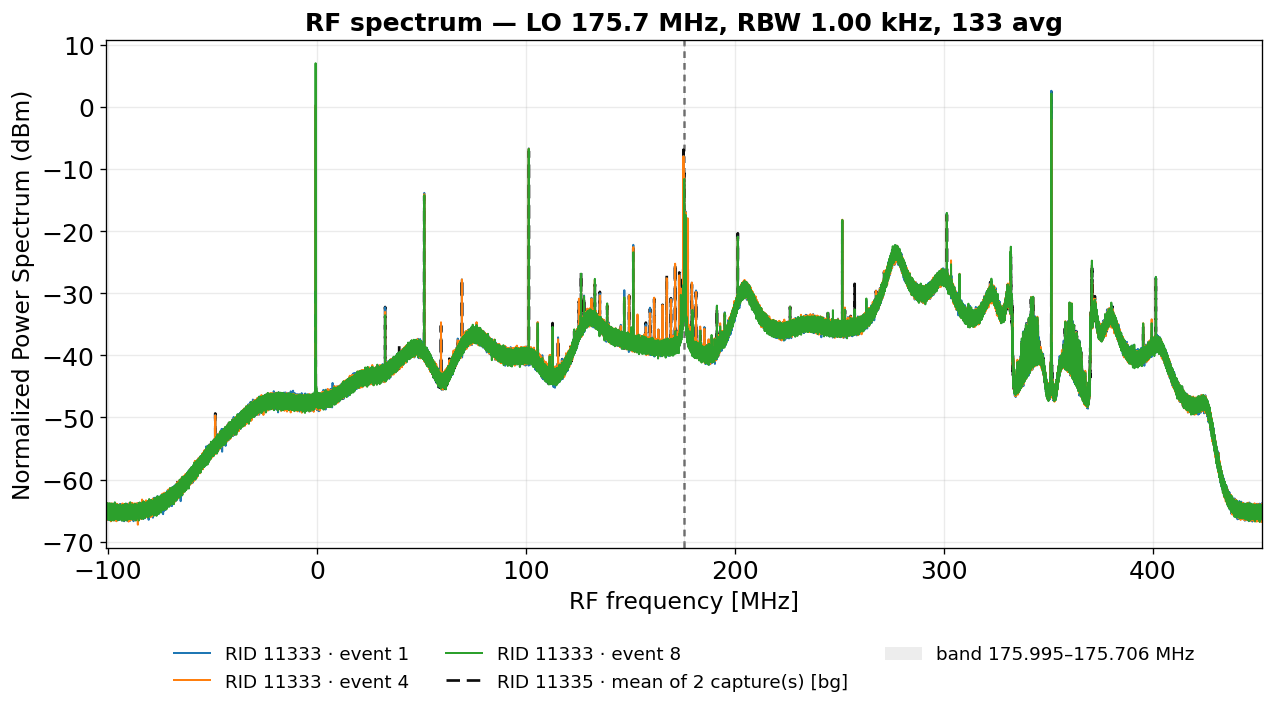

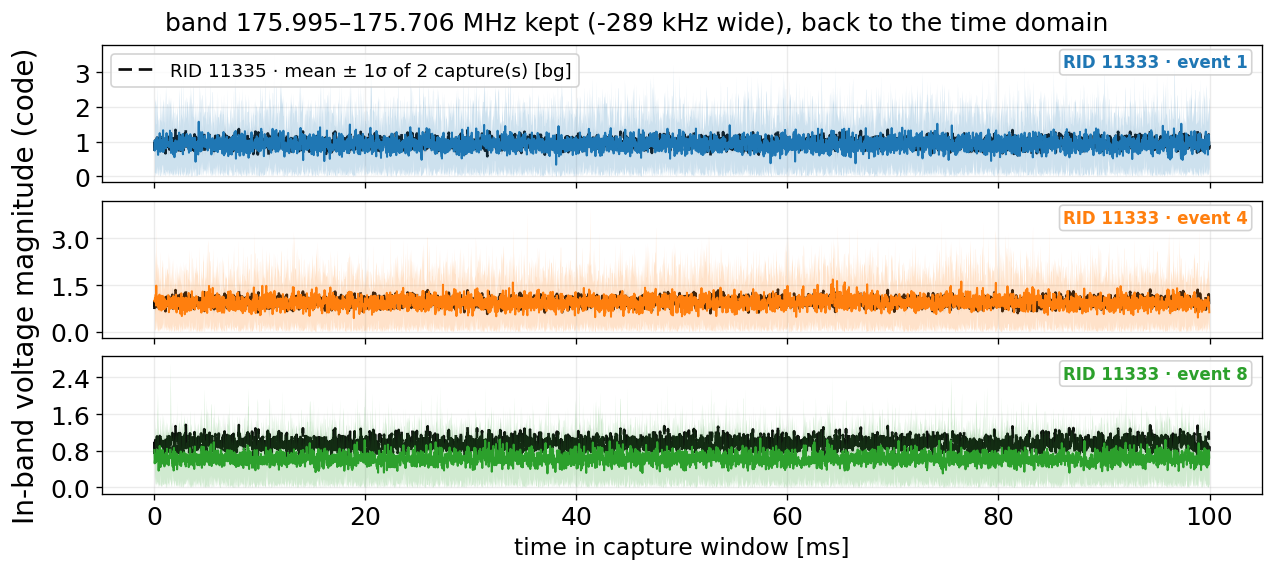

In [13]:
import edes.experiments.analysis.rfsoc_spectrum as S
from matplotlib import pyplot as plt

# S.plot_rf_spectrum(11345, rbw_khz=10, span_mhz=4, band_mhz=(175.3, 175.5))
# S.plot_band_filtered(11345, band_mhz=(175.3, 175.5), time_unit="ms")
S.analyze(11333, noise=11335, events=[1,4,8],rbw_khz=1, span_mhz=None, band_mhz=(175.995, 175.70566))
plt.show()

In [1]:
import edes.experiments.analysis.rfsoc_spectrum as S
import matplotlib.pyplot as plt


In [ ]:

run  = S._as_run(11333)
ons  = S.windows_from_pulse(run, phase="on",  guard_us=20, time_unit="ms")
offs = S.windows_from_pulse(run, phase="off", guard_us=20, time_unit="ms")

common = dict(noise=11335, events=[2, 5, 8], rbw_khz=5, sideband=-1,#band_mhz=(351, 353),
              center_mhz=175.7, span_mhz=4, time_unit="ms", noise_on_top=True)

out_on  = S.analyze(11333, tlim=ons,  **common)     # 40 drive bursts

plt.show()
out_off = S.analyze(11333, tlim=offs, **common)     # 39 quiet gaps
plt.show()


RF spectrum — RBW 5.00 kHz, 132 averages
  RID 11333 · event 1          peak   176.0033 MHz    -6.7 dBm   floor   -31.7 dBm
  RID 11333 · event 2          peak   176.0033 MHz    -6.7 dBm   floor   -31.6 dBm
  RID 11333 · event 3          peak   176.0033 MHz    -6.6 dBm   floor   -31.5 dBm
  RID 11333 · event 4          peak   176.0033 MHz    -6.8 dBm   floor   -31.6 dBm
  RID 11333 · event 5          peak   176.0033 MHz    -6.6 dBm   floor   -31.5 dBm
  RID 11333 · event 6          peak   176.0033 MHz    -6.8 dBm   floor   -31.6 dBm
  RID 11333 · event 7          peak   176.0033 MHz    -6.9 dBm   floor   -31.6 dBm
  RID 11333 · event 8          peak   175.6667 MHz   -11.3 dBm   floor   -31.8 dBm
  RID 11335 · mean of 2 capture(s) [bg] peak   176.0033 MHz    -5.8 dBm   floor   -31.6 dBm

Band 175.695–175.705 MHz kept (10 kHz wide)
  RID 11335 · mean ± 1σ of 2 capture(s) [bg] level    0.184 ± 0.056   (counts)
  RID 11333 · event 1          rms    0.192   peak     0.52   (counts)
  RID 1

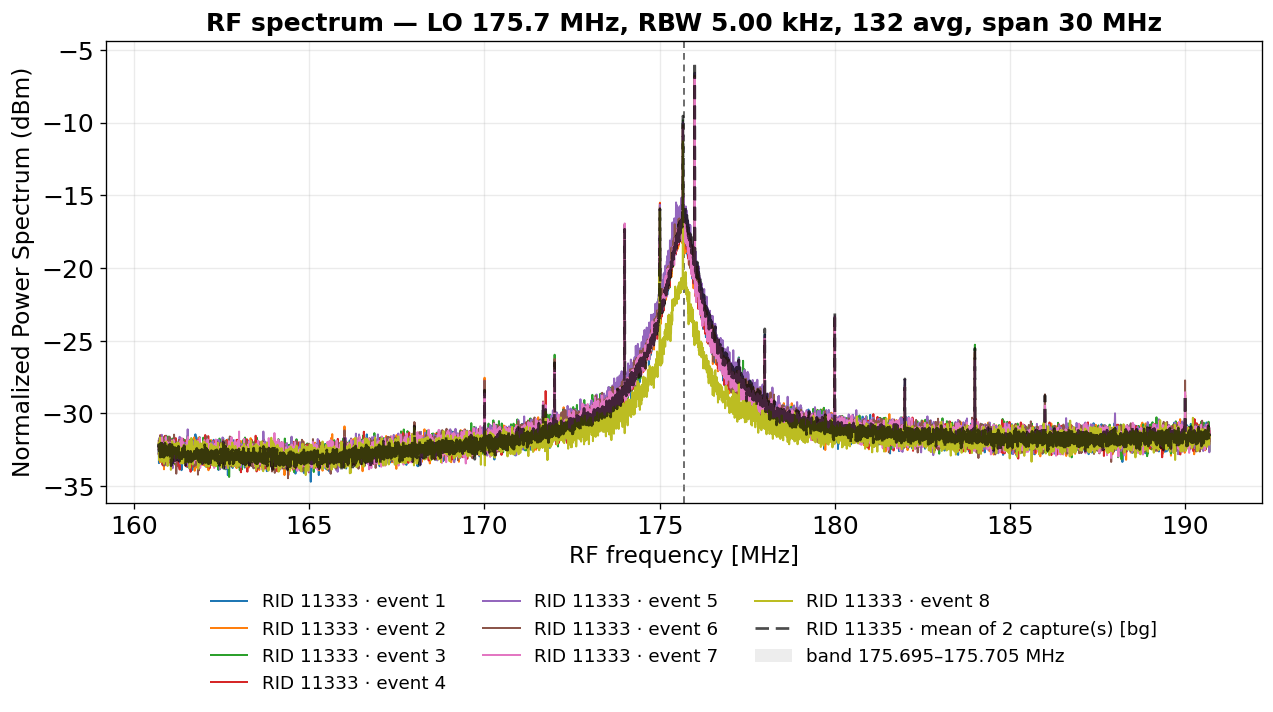

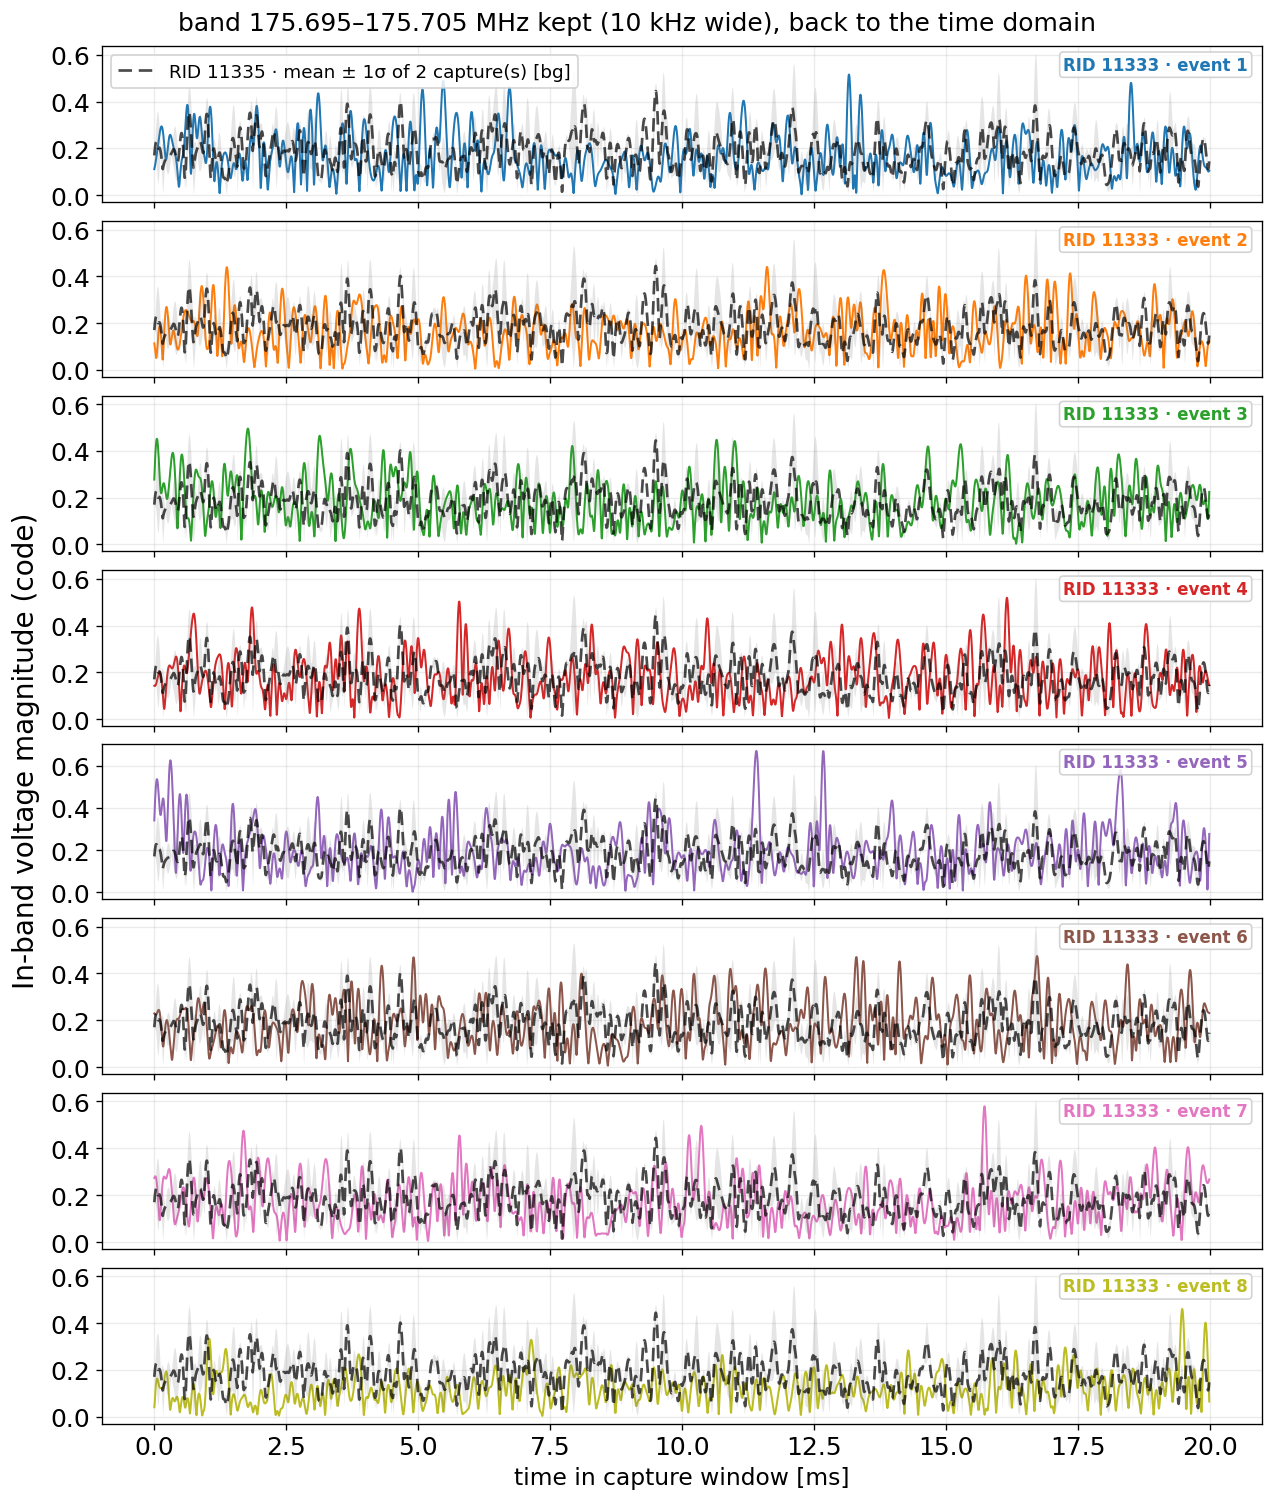

In [35]:
common = dict(rbw_khz=5, sideband=-1, band_mhz=(175.695, 175.705),
              center_mhz=175.7, span_mhz=30, time_unit="ms", noise_on_top=True)

out_on  = S.analyze([11333],noise=11335,tlim=[(0, 20)], **common)     # 40 drive bursts

plt.show()

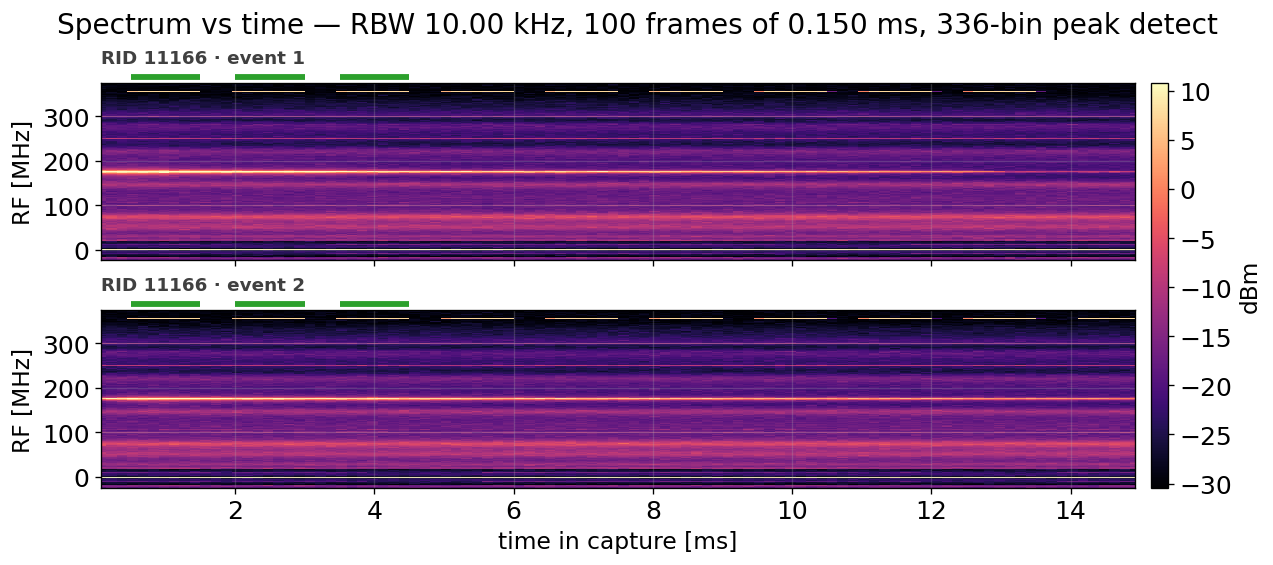

In [ ]:
S.plot_spectrogram(11166, rbw_khz=10, nframes=100, navg=1,
                   center_mhz=175.7, span_mhz=40, sideband=-1, time_unit="ms",pulse=True)
                   #band_mhz=(176.0033, 174.0033))
plt.show()

[spectrogram] frames are 1000 us long against a 1500 us pulse period (1000 on / 500 off) — a frame is longer than the 500 us phase, so the gating is ALIASED. Use nframes>=801. (navg=1 also narrows each frame to its first segments, which strobes the train harder — navg=0 averages the whole frame.)
[spectrogram] frames are 1000 us long against a 1500 us pulse period (1000 on / 500 off) — a frame is longer than the 500 us phase, so the gating is ALIASED. Use nframes>=801. (navg=1 also narrows each frame to its first segments, which strobes the train harder — navg=0 averages the whole frame.)
[spectrogram] frames are 1000 us long against a 1500 us pulse period (1000 on / 500 off) — a frame is longer than the 500 us phase, so the gating is ALIASED. Use nframes>=801. (navg=1 also narrows each frame to its first segments, which strobes the train harder — navg=0 averages the whole frame.)
[spectrogram] frames are 1000 us long against a 1500 us pulse period (1000 on / 500 off) — a frame is long

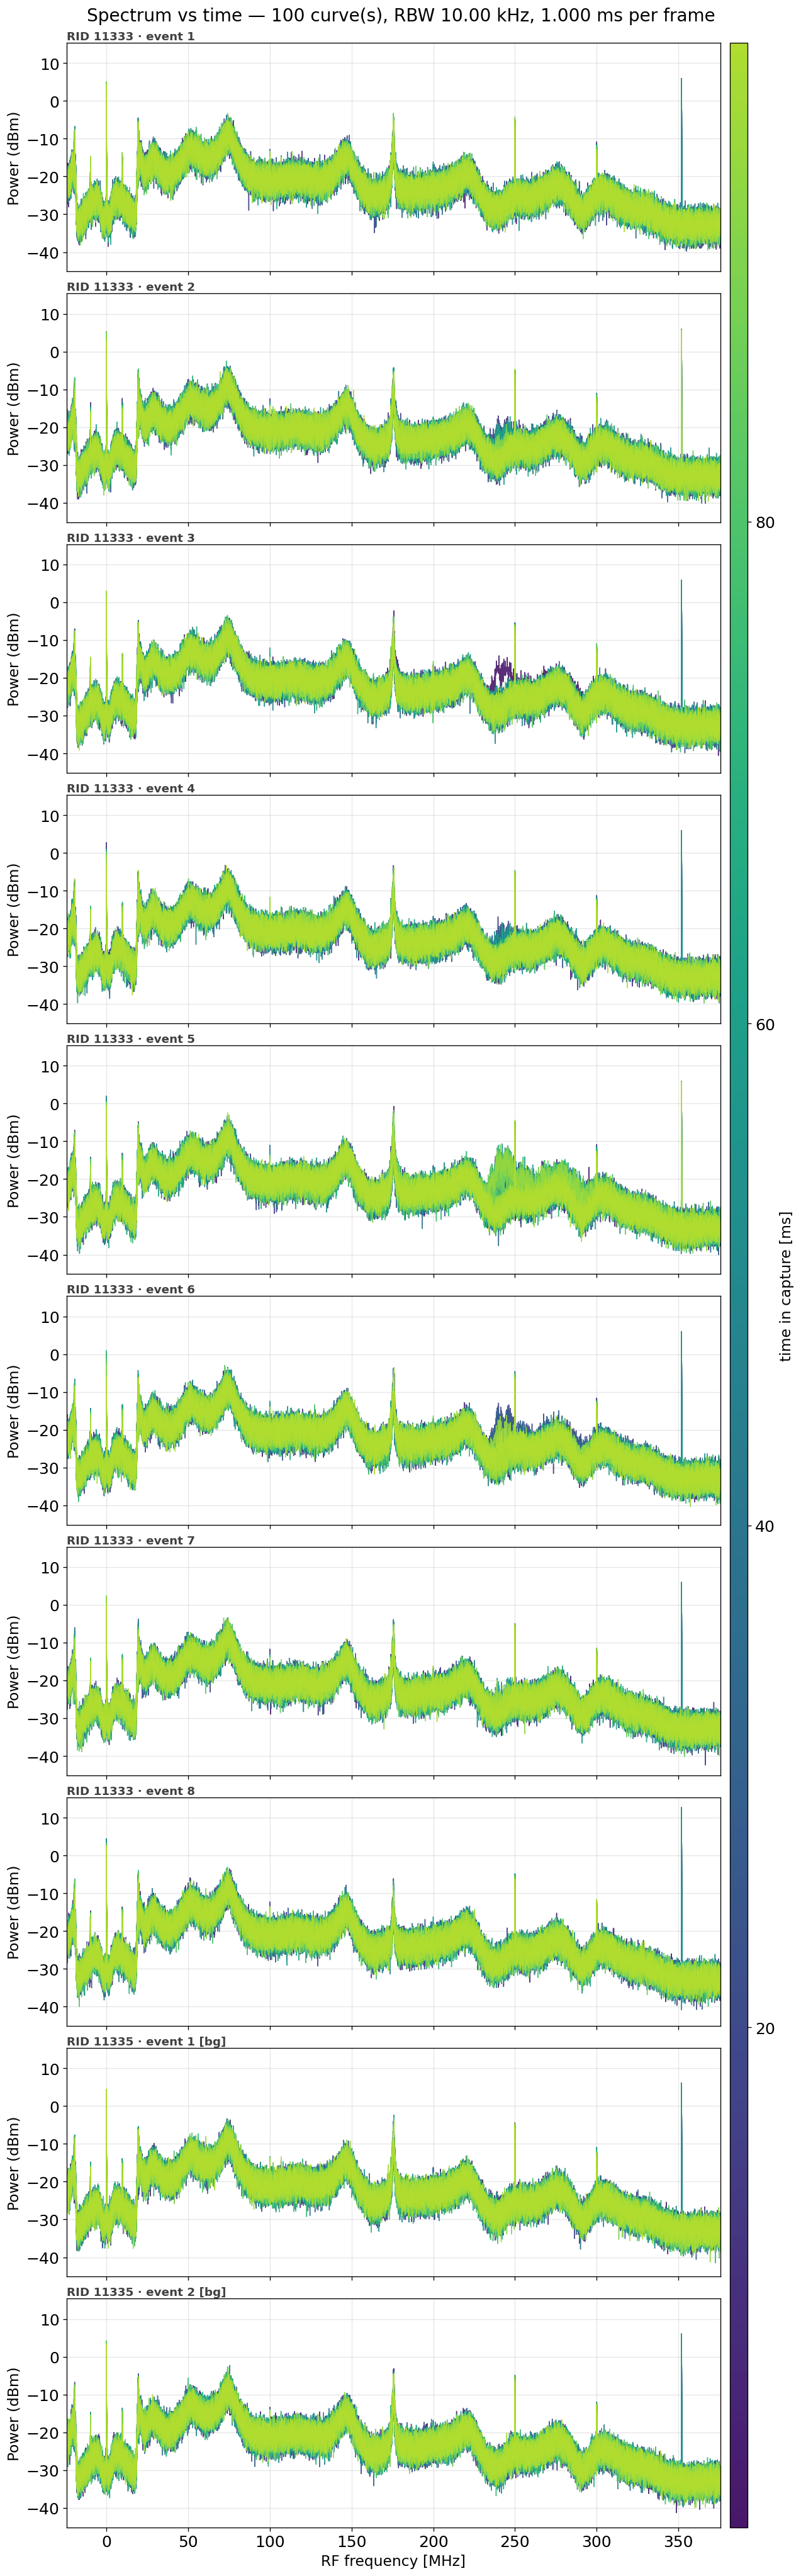

In [34]:
S.plot_spectra_vs_time(11333,rbw_khz=10, nframes=100, navg=1, noise=11335,
                       center_mhz=175.7, span_mhz=400, sideband=-1,
                       time_unit="ms", guard_us=20)
plt.show()

## Clocks & caveats

The ARTIQ host and the RFSoC board are both NTP-synced, so every wall-clock
value is directly comparable to ~10 ms.

| quantity | source | accuracy |
|---|---|---|
| RFSoC **captured** event / MR snapshot time | manifest `t_wall` | exact (host-measured at detection, lags the true crossing < a few ms) |
| RFSoC **crossing** time (`t_start + t_rel_s`) | tProc `iter` / startup `pps` | scale error ~0.1–0.5 % → ±~1 s at 500 s in; check `rfsoc_pps` ≈ 1.5e6 |
| SA trace time | `sa_wall_start` … `sa_wall` bracket | the sweep sits in that bracket; **±overhead/2** (~±40 ms on this bench — `*OPC?`/transfer). `summary()` prints it. |
| SA trace time (older runs) | stretched estimate / end-only stamp | **±10 s** / **+lag** — the plot note says which is in use |
| DDR4 sample 0 | crossing (tProc trigger) | ~µs; the pulse overlay adds `crossing_to_pulse_us` (~7 µs) |

For ms-level SA↔RFSoC alignment you need a hardware/level trigger, or shrink the
SA acquisition overhead (swept not FFT mode, `N_avg=1`, keep `:INIT:CONT` OFF).
